<img src="logoucm.png" style="height: 250px">
<center style="color:#888"><br/></center>




<font size="6"><center style="color:#1B4F72"><br/>
Técnicas de Simulación</center></font>
<font size="4"><center style="color:#1B4F72"><br/>
Máster en Ingeniería Matemática</center></font>

<font size="5"><center><span style="color:#117864">***Nombre y Apellidos:  Ana Marta Oliveira dos Santos, Mario Queipo Silva y Siria Catherine Iniguez Brito***</span></center></font>

## Importamos las librerías necesarias

In [1]:
import numpy as np
import pandas as pd
from math import sin, cos, sqrt, log, exp, pi
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import t as t_student
import scipy.stats as stats
from scipy.special import comb
from scipy.stats import norm

<font size="6"><center><span style="color:blue">***Práctica 1: Generadores de números pseudoaleatorios***</span></center></font>

## 1. Método congruencial


Considerad los siguientes valores para los parámetros en el método congruencial:  
* m=2**(31)-1
* a=16807
* b=0  

y la semilla inicial en todos los casos será:  
* x0=123456789

In [2]:
m=2**(31)-1
a=16807
b=0
x0=123456789

In [3]:
def generador_congruencial_rapido(n, m, a, c, x0):
    u = np.zeros(n)
    x = x0
    for i in range(n):
        x = (a * x + c) % m
        u[i] = x / m
    return u, x

1. Para comprobar que está correctamente programado, generar 100 valores U(0,1). Éstos deben cumplir:  

    * $\overline{x} = 0.47682692$
    * $S^2_n = 0.09155876$
    * $S^2_{n-1} = 0.09248360$
    * $u1 = 0.2184183 ~ u2 = 0.95631758 ~ u3 = 0.82950923 . . .$  
    

2. Justificar que los números generados proceden de una distribución U(0,1).

## 2. Box-Müller


In [4]:
def generador_box_muller_rapido(n_pares, m, a, c, x0):
    u_total, x_final = generador_congruencial_rapido(2 * n_pares, m, a, c, x0)
    u1 = u_total[0::2]
    u2 = u_total[1::2]
    x = np.sqrt(-2*np.log(u1)) * np.cos(2*np.pi*u2)
    y = np.sqrt(-2.0 * np.log(u1)) * np.sin(2.0 * np.pi * u2)
    return x, y, x_final


1. Para comprobar que está correctamente programado, generar 100 valores N(0,1). Éstos deben cumplir:

    * $\overline{x} = 0.02737136$
    * $S^2_n = 1.079609$
    * $S^2_{n-1} = 1.090514$
    * $u1 = 1.679040257 ~ u2 = −0.566059812 ~ u3 = 1.212934217 . . .$
    * $\overline{y} = −0.1220177$
    * $S^2_n = 1.040119$
    * $S^2_{n-1} = 1.050626$
    * $u1 = −0.47276880 ~ u2 = −0.23112413 ~ u3 = 0.53503714 . . .$  
    

2. Justificar que los números generados proceden de una distribución N(0,1).

## 3. Método Marsaglia


1. Para comprobar que está correctamente programado, generar 100 valores N(0,1). Éstos deben cumplir:

    * $\overline{x} = 0.2159052$
    * $S^2_n = 0.7075141$
    * $S^2_{n-1} = 0.7146607$
    * $u1 = 1.24295692 ~ u2 = −0.13445768 ~ u3 = −0.30786186 . . .$
    * $\overline{y} = −0.1732801$
    * $S^2_n = 0.9229105$
    * $S^2_{n-1} = 0.9322328$
    * $u1 = 0.23272421 ~ u2 = −0.68882581 ~ u3 = −0.49533179 . . .$
    
    
2. Justificar que los números generados proceden de una distribución N(0,1).


## 2. Box-Müller antitéticas

## 2. Marsaglia antitéticas

## 4. t-Student


In [5]:
def generar_chi_cuadrado(n_muestras, n_gl, m, a, c, x0):
    """
    Genera n_muestras de una distribución Chi-cuadrado con n_gl grados de libertad.
    """
    X = np.zeros(n_muestras)
    semilla = x0

    if n_gl % 2 == 0:
        # Caso n par: X = -2 * suma(ln(ui))
        k = n_gl // 2
        for i in range(n_muestras):
            u, semilla = generador_congruencial_rapido(k, m, a, c, semilla)
            X[i] = -2 * np.sum(np.log(u))
    else:
        # Caso n impar: X = Y + Z^2, donde Y ~ Gamma((n-1)/2, 1/2)
        k = (n_gl - 1) // 2
        for i in range(n_muestras):
            # Parte Gamma
            u, semilla = generador_congruencial_rapido(k, m, a, c, semilla)
            y_gamma = -2 * np.sum(np.log(u))
            # Parte Normal (se usa box muller y se toma solo la segunda componente)
            z1, z2, semilla = generador_box_muller_rapido(1, m, a, c, semilla)
            X[i] = y_gamma + z2[0]**2

    return X, semilla

def generar_t_student(n_muestras, n_gl, m, a, c, x0):
    """
    Genera n_muestras de una t-Student con n_gl grados de libertad.
    Utiliza el algoritmo: X = Z / sqrt(Y/n)
    """
    X = np.zeros(n_muestras)
    semilla = x0

    for i in range(n_muestras):
        # 1. Generar Z ~ N(0,1)
        z1, z2, semilla = generador_box_muller_rapido(1, m, a, c, semilla)
        Z = z2[0]

        # 2. Generar Y ~ Chi^2_n
        # Nota: La semilla se actualiza dentro de generar_chi_cuadrado
        Y, semilla = generar_chi_cuadrado(1, n_gl, m, a, c, semilla)

        # 3. Aplicar fórmula
        X[i] = Z / np.sqrt(Y[0] / n_gl)

    return X, semilla

Comprobación:

In [6]:
n_muestras = 100
n_gl = 10


t_valores, semilla_final = generar_t_student(n_muestras, n_gl, m, a, b, x0)

def comprobacion_numerica(t_valores):
    """Realiza los cálculos estadísticos básicos para comprobar con el ejercicio."""
    media = np.mean(t_valores)
    var_n = np.var(t_valores, ddof=0)
    var_n_1 = np.var(t_valores, ddof=1)

    print("=== Comprobación Numérica ===")
    print(f"Media (x_bar): {media:.8f}")
    print(f"Varianza S^2_n: {var_n:.6f}")
    print(f"Varianza S^2_n-1: {var_n_1:.6f}")
    print(f"Primeros 3 valores:")
    print(f"u1 = {t_valores[0]:.9f}")
    print(f"u2 = {t_valores[1]:.9f}")
    print(f"u3 = {t_valores[2]:.9f}\n")

comprobacion_numerica(t_valores)

=== Comprobación Numérica ===
Media (x_bar): -0.00024283
Varianza S^2_n: 1.515859
Varianza S^2_n-1: 1.531171
Primeros 3 valores:
u1 = -0.442199721
u2 = 0.558411054
u3 = 0.006160887



Para comprobar que está correctamente programado, generar 100 valores de la variable aleatoria $t_{10}$.
Éstos deben cumplir:
* $\overline{x} = −0.00024283$
* $S^2_n = 1.515859$
* $S^2_{n-1} = 1.531171$
* $u1 = −0.442199721 ~ u2 = 0.558411054 ~ u3 = 0.006160887 . . .$


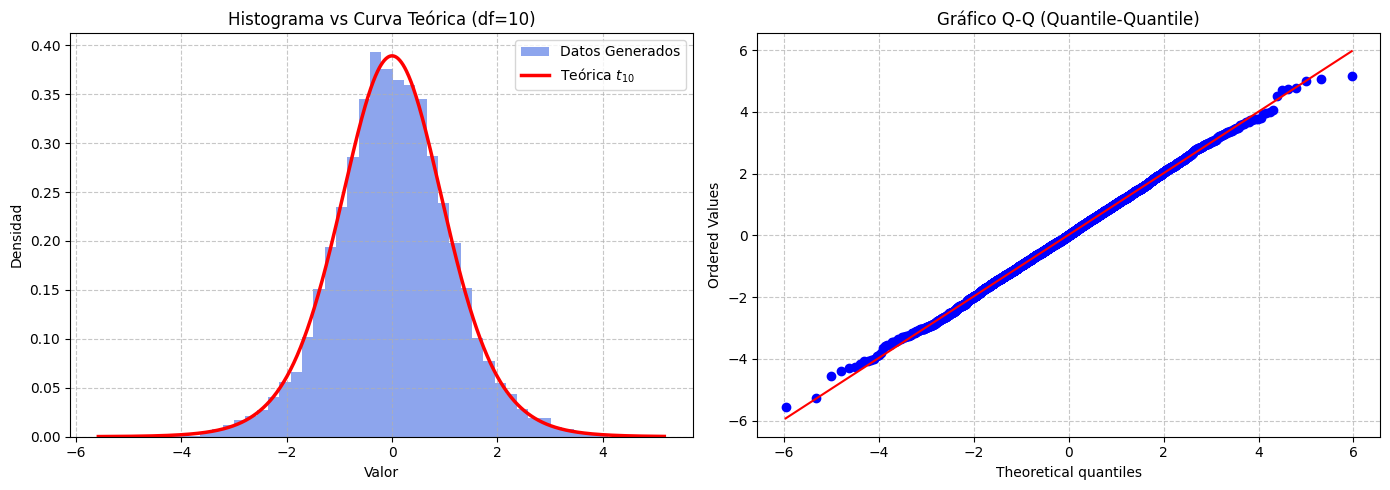

=== Test de Kolmogorov-Smirnov ===
Estadístico D : 0.0096
P-valor       : 0.3159
Conclusión: No hay evidencia para rechazar H0.
Hipótesis Nula (H0): Los datos provienen de una t-Student con 10 grados de libertad.


In [7]:
def validacion_grafica_y_estadistica(valores, n_gl):
    """
    Genera gráficos y aplica el Test de Kolmogorov-Smirnov para validar
    que 'valores' sigue una distribución t-Student con 'n_gl' grados de libertad.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Gráfico de Densidad (Histograma vs PDF Teórica)
    ax1.hist(valores, bins=50, density=True, alpha=0.6, color='royalblue', label='Datos Generados')

    # Curva teórica de la t-Student usando scipy
    x_teorico = np.linspace(min(valores), max(valores), 1000)
    pdf_teorica = stats.t.pdf(x_teorico, n_gl)
    ax1.plot(x_teorico, pdf_teorica, 'r-', lw=2.5, label=f'Teórica $t_{{{n_gl}}}$')

    ax1.set_title(f'Histograma vs Curva Teórica (df={n_gl})')
    ax1.set_xlabel('Valor')
    ax1.set_ylabel('Densidad')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # 2. Q-Q Plot
    stats.probplot(valores, dist="t", sparams=(n_gl,), plot=ax2)
    ax2.set_title('Gráfico Q-Q (Quantile-Quantile)')
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # 3. Contraste de Hipótesis: Kolmogorov-Smirnov
    # Hipótesis Nula (H0): Los datos provienen de una t-Student con n_gl grados de libertad
    stat, p_value = stats.kstest(valores, 't', args=(n_gl,))

    print("=== Test de Kolmogorov-Smirnov ===")
    print(f"Estadístico D : {stat:.4f}")
    print(f"P-valor       : {p_value:.4f}")

    if p_value > 0.05:
        print("Conclusión: No hay evidencia para rechazar H0.")
        print(f"Hipótesis Nula (H0): Los datos provienen de una t-Student con {n_gl} grados de libertad.")
    else:
        print("Conclusión: Se rechaza H0.")
        print("El generador NO parece ajustarse a una t-Student.")

muestras_prueba, _ = generar_t_student(10000, 10, m, a, b, x0)
validacion_grafica_y_estadistica(muestras_prueba, 10)

<font size="6"><center><span style="color:blue">***Práctica 2***</span></center></font>

1. Generar un movimiento browniano unidimensional para T=100 con ∆𝑡=1 según la expresión:

<font size="3"><center>$X \leftarrow X + \sqrt{\Delta t } Z$ donde $Z \sim \mathcal{N}(0,1)$</center></font>

2. Generar 4 movimientos brownianos usando los valores de la distribución Normal generados mediante el seno y coseno del método de Box-Müller y también con variables antitéticas.

3. Generar 4 movimientos brownianos usando los valores de la ditribución normal generados mediante el método de Marsaglia y también con variables antitéticas.

<font size="2">*Nota: Reiniciar la semilla cada vez que se use un método nuevo.
Representar gráficamente las ocho trayectorias obtenidas. Verificar con estas imágenes:*</font>

<div class="pull-left"><img src="4movBM.png" style="height: 300px"></div>
<img src="4movMG.png" style="height: 300px">

4. Representar graficamente 1 movimiento browniano bidimensional.

<font size="7"><center><span style="color:blue">***Práctica 3***</span></center></font>

<font size="6"><center><span style="color:blue">***Práctica 3.1***</span></center></font>

<font size="4" color=blue>**Apartado a**</font>
***

Obtener los valores de una opción call y una opción put europeas con vencimiento $T$. Dar la estimación del valor y la precisión si:  

$$
V_{\mathrm{call}} = e^{-r_c t} \mathbb{E}_{\mathrm{riesgo~neutro}} [\textrm{payoff}] = (1+r)^{-t} \mathbb{E}_{\mathrm{riesgo~neutro}}[\textrm{payoff}].
$$

- **(a.1.)** Obtener el valor de una opción call usando la fórmula de Black-Scholes:  

$$
V_{\mathrm{call}}(S,t) = Se^{-d_c t} \Phi(d_1) - Ke^{-r_c t} \Phi(d_2),
$$

donde:
$$
d_1 = \frac{\ln(S/K) + (r_c -d_c + 0.5 \sigma^2)t}{\sigma \sqrt{t}}, \quad d_2 = d_1 -\sigma\sqrt{t}.
$$

**Datos:**
- $r = 0.03$
- Strike = $14$
- Plazo $T = 1,2,3$
- $\sigma = 0.3$
- $S_0 = 14$
- $d = 0$

<font size="2">**Nota:** La varianza de la estimación del valor es $S^2_{\mathrm{call}} = (e^{-r_c t})^2 S^2_{\mathrm{\overline{payoff}}}$.
    
<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=1.856787;V_{\mathrm{put}}=1.449020$.</font>



<font size="4" color=blue>**Apartado b**</font>
***
Obtener los valores de una opción call y una opción put europeas con vencimiento $T = 1$ (con los mismos datos del apartado anterior). Dar la estimación del valor y la precisión si:  

$$
V_{\mathrm{call}} = e^{-r_c t} \mathbb{E}_{\mathrm{riesgo~neutro}}[\textrm{payoff}] = (1+r)^{-t} \mathbb{E}_{\mathrm{riesgo~neutro}}[\textrm{payoff}].
$$

- **(b.1.)** Obtener el valor final del subyacente mediante la expresión en el plazo final:  

$$
S(t) = S(0) e^{(r_c - d_c - 0.5\sigma^2)t + \sigma \sqrt{t}\mathcal{N}(0,1)}.
$$

<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=1.919841;Varianza=10.065818;Precisión=0.196879$.</font>
    
- **(b.2.)** Obtener el valor final del subyacente mediante simulación dinámica con $\Delta t = 1/12$ y la expresión (Lema de Itô):  

$$
S \leftarrow S e^{(r_c - d_c - 0.5\sigma^2)\Delta t + \sigma \sqrt{\Delta t}\mathcal{N}(0,1)}.
$$

<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=2.008849;Varianza=10.349455;Precisión=0.199633$.</font>
    
- **(b.3.)** Obtener el valor final del subyacente mediante simulación dinámica con $\Delta t = 1/12$ y el mecanismo de transición. (Ecuación estocástica)  

$$
S \leftarrow S + S(r_{\Delta t} - d_{\Delta t})+\sigma S \sqrt{\Delta t}\mathcal{N}(0,1) = S(1+r-d)^{\Delta t} + \sigma S \sqrt{\Delta t} \mathcal{N}(0,1)
$$

<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=2.005745;Varianza=10.020386;Precisión=0.196434$.</font>
    
- **(b.4.)** Usando el valor final del subyacente mediante la expresión en el plazo final, determinar el tamaño muestral para que la estimación sea de un céntimo de Euro.


In [8]:
from scipy.stats import t as t_student

# 1. Configuración de parámetros
S0 = 14.0
K = 14.0
r_discreta = 0.03
sigma = 0.3
dc = 0.0
tiempos = [1, 2, 3]
n_sim = 1000
dt = 1/12  # Incremento de tiempo mensual (b.2)

# Parámetros para el generador aleatorio (LCG)
m = 2**31 - 1
a = 16807
c = 0

# 3. Simulación con la nueva fórmula (Ecuación estocástica)
rc = np.log(1 + r_discreta)

print(f"{'T':<4} | {'V_call':<10} | {'Varianza':<10} | {'Precisión':<10} | {'V_put':<10}")
print("-" * 75)

for t in tiempos:
    seed_dinamica = 123456789
    payoffs_call = []
    payoffs_put = []
    n_pasos = int(t * 12)

    for _ in range(n_sim):
        S = S0
        for _ in range(n_pasos):
            # Llamada directa a Box-Müller para obtener normales dinámicamente
            _, y, seed_dinamica = generador_box_muller_rapido(1, m, a, c, seed_dinamica)
            Z = y[0]

            # --- NUEVA FÓRMULA (Apartado b.3) ---
            # S = S * (1 + r - d)**dt + sigma * S * sqrt(dt) * Z
            S = S * (1 + r_discreta - dc)**dt + sigma * S * np.sqrt(dt) * Z

        payoffs_call.append(np.maximum(S - K, 0))
        payoffs_put.append(np.maximum(K - S, 0))

    # Cálculos estadísticos
    v_call = np.exp(-rc * t) * np.mean(payoffs_call)
    v_put = np.exp(-rc * t) * np.mean(payoffs_put)
    s2_payoff_call = np.var(payoffs_call, ddof=1)

    varianza_estim = np.exp(-2 * rc * t) * s2_payoff_call
    t_crit = t_student.ppf(0.975, n_sim - 1)
    precision = t_crit * np.sqrt(varianza_estim / n_sim)

    print(f"{t:<4} | {v_call:<10.6f} | {varianza_estim:<10.6f} | {precision:<10.6f} | {v_put:<10.6f}")

T    | V_call     | Varianza   | Precisión  | V_put     
---------------------------------------------------------------------------
1    | 2.005745   | 10.020386  | 0.196434   | 1.392958  
2    | 2.821879   | 26.324605  | 0.318387   | 1.859360  
3    | 3.529372   | 46.426739  | 0.422823   | 2.178953  


<font size="6"><center><span style="color:blue">***Práctica 3.2***</span></center></font>

- **(b.)** Obtener mediante simulación el valor de una estrategia **butterfly** formada por la compra de una opción call europea con strike $K$, la compra de otra opción europea con strike $K'>K$ y la venta de dos opciones call europeas con strike $K''$ tal que $K<K''<K'$, todas sobre el mismo subyacente.  
Aplicarlo suponiendo los datos de las prácticas anteriores con $K = 14, K' = 16$ y $K'' = 15$.

- **(a.)** Teniendo en cuenta las consideraciones anteriores y dependiendo del resultado del subyacente define y muestra la tabla de payoffs antes de desarrollar el código.  

- **(c.)** Grafica el resultado y comprueba que el gráfico tiene la misma forma que lo ya visto en la parte de teoría.

- **(d.)** Muestra graficamente cual sería el beneficio obtenido, es decir, considerando el coste de la prima.

- **(e.)** Los mismos apartados anteriores para una estrategia **strangle** (tipo cuna, forma parte de la especulativas) formada por la compra de una opción call europea con strike $K'$ y una opción put con strike $K$, con $K'>K$.

<font size="6"><center><span style="color:blue">***Práctica 4***</span></center></font>

Obtener mediante simulación el valor de una opción call europea vainilla con dividendos para plazos T=1,2,3, pero cuyos incrementos se rigen según una distribución t-Student. Dar la estimación del valor y la precisión y comparar con el resultado de la práctica anterior. Utilizar los mismos datos que en la práctica anterior y n=6. Utilizar para la evolución del subyacente:

$$
S \leftarrow S e^{(r_c - d_c)\Delta t} + \sigma S \sqrt{\Delta t}\frac{t_n}{\sqrt{n/(n-2)}}
$$

<font size="2">**Nota:** Recordad que la varianza de una t-Student con n grados de libertad es $\frac{n}{n-2}$, con lo que al sustituir la Normal por la t-Student, ha de hacerse con ésta tipificada.
    
<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=1.840173;Varianza=8.169188;Precisión=0.177363$.</font>

In [15]:
# 1. Configuración de parámetros
S0 = 14.0
K = 14.0
r_discreta = 0.03
rc = np.log(1 + r_discreta)
sigma = 0.3
dc = 0.0

# Parámetros
m = 2**31 - 1
a = 16807
c = 0

# Parámetros de la simulación
n_gl = 6            # Grados de libertad de la t-Student
n_sim = 1000        # Número de simulaciones
dt = 1/12           # Paso de tiempo (mensual)
tiempos = [1, 2, 3] # Plazos T en años

# 2. Simulación Dinámica con t-Student
print(f"{'T':<4} | {'V_call':<12} | {'Varianza':<12} | {'Precisión':<12}")
print("-" * 50)

for t in tiempos:
  seed_dinamica = 123456789
  payoffs_call = []
  n_pasos = int(t * 12)

  for _ in range(n_sim):
      S = S0
      for _ in range(n_pasos):
          # 1. Generar un valor de la distribución t-Student
          t_val_array, seed_dinamica = generar_t_student(1, n_gl, m, a, c, seed_dinamica)
          t_val = t_val_array[0]

          # 2. Tipificar la variable t-Student
          # Se divide por su desviación típica: sqrt(n / (n - 2))
          z_tipificada = t_val / np.sqrt(n_gl / (n_gl - 2))

          # 3. Evolución del subyacente
          S = S * np.exp((rc - dc) * dt) + sigma * S * np.sqrt(dt) * z_tipificada

      # Calcular payoff de la opción Call en el vencimiento
      payoffs_call.append(np.maximum(S - K, 0))

  # 3. Cálculos estadísticos para este plazo T
  v_call = np.exp(-rc * t) * np.mean(payoffs_call)
  s2_payoff_call = np.var(payoffs_call, ddof=1)

  varianza_estim = np.exp(-2 * rc * t) * s2_payoff_call
  t_crit = t_student.ppf(0.975, n_sim - 1) # Usando alfa = 0.05
  precision = t_crit * np.sqrt(varianza_estim / n_sim)

  print(f"{t:<4} | {v_call:<12.6f} | {varianza_estim:<12.6f} | {precision:<12.6f}")

T    | V_call       | Varianza     | Precisión   
--------------------------------------------------
1    | 1.840173     | 8.169188     | 0.177363    
2    | 2.664039     | 20.821543    | 0.283159    
3    | 3.463945     | 38.336755    | 0.384222    


### Comparativa de Resultados: Normal vs t-Student (n=6)

En esta sección se compara el valor de la opción call europea obtenido mediante la simulación con incrementos bajo una distribución t-Student tipificada (Práctica 4) frente a los distintos modelos de la práctica anterior (Black-Scholes y simulaciones con distribución Normal).

#### 1. Comparativa de Valores Estimados (V_call)

| Plazo (T) | Práctica 4 (t-Student) | a.1 (Black-Scholes) | b.1 (Valor Final) | b.2 (Dinámica 1) | b.3 (Trans. Estocástica) |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **T = 1** | 1.840173 | 1.856787 | 1.919841 | 2.008849 | 2.005745 |
| **T = 2** | 2.664039 | 2.708070 | 2.807325 | 2.820939 | 2.821879 |
| **T = 3** | 3.463945 | 3.381072 | 3.513282 | 3.512672 | 3.529372 |

#### 2. Tabla de Errores Relativos (%)
Se define el error relativo porcentual como: ($ \frac{|V_{t-Student} - V_{Normal}|}{V_{Normal}})  * 100$. Esta métrica nos permite observar cuánto se desvía la valoración con t-Student respecto a las dinámicas normales.

| Plazo (T) | Error Relativo vs a.1 (B-S) | Error Relativo vs b.1 | Error Relativo vs b.2 | Error Relativo vs b.3 |
| :---: | :---: | :---: | :---: | :---: |
| **T = 1** | **0.89 %** | 4.15 % | 8.40 % | 8.25 % |
| **T = 2** | **1.63 %** | 5.10 % | 5.56 % | 5.59 % |
| **T = 3** | **2.45 %** | 1.40 % | 1.39 % | 1.85 % |

#### 3. Comparativa de Varianza y Precisión
Al evaluar métodos de simulación Monte Carlo, es fundamental no solo observar el valor final, sino la incertidumbre (precisión) y varianza de nuestra estimación.

| Plazo (T) | Varianza (t-Student) | Varianza Media (Normal b.2/b.3) | Precisión (t-Student) | Precisión Media (Normal b.2/b.3) |
| :---: | :---: | :---: | :---: | :---: |
| **T = 1** | **8.1691** | ~ 10.1849 | **0.1773** | ~ 0.1980 |
| **T = 2** | **20.8215** | ~ 26.6600 | **0.2831** | ~ 0.3204 |
| **T = 3** | **38.3367** | ~ 47.1929 | **0.3842** | ~ 0.4262 |

---

### Análisis y Conclusiones de la Comparativa

1. **Aproximación al valor teórico (Black-Scholes):** Los valores obtenidos con la simulación t-Student (Práctica 4) estan muy cerca del valor teórico analítico de Black-Scholes (apartado a.1). Como se observa en la tabla de errores relativos, la desviación frente a B-S es mínima (entre 0.89% y 2.45%), siendo mucho menores que las desviaciones que presentaban las propias simulaciones de trayectorias con distribución normal (b.2 y b.3) en T=1 y T=2.
   
2. **Impacto en la Varianza y Precisión:**
   Al incorporar la distribución t-Student tipificada (multiplicada por el factor $\sqrt{\frac{n}{(n-2)}}$ para ajustar la varianza al marco estandarizado), observamos una **mejora clara en la precisión de la simulación**.
   * Las varianzas muestrales del *payoff* en la Práctica 4 (8.16, 20.82, 38.33) son visiblemente inferiores a las obtenidas en las dinámicas 1 y de transición estocástica de la práctica anterior (que rondaban los 10.1, 26.6 y 47.1 respectivamente).
   * En consecuencia, **el radio del intervalo de confianza (Precisión) se estrecha**. Para T=1 pasamos de una precisión de ~0.198 a 0.177, lo que indica que la simulación converge con menos ruido estadístico en las estimaciones.

3. **Efecto de las colas pesadas:**
   Aunque la t-Student con n=6 tiene colas más pesadas que la Normal (lo cual suele encarecer las opciones muy *out-of-the-money*), el proceso de estandarización aplicado garantiza que la volatilidad global coincida. Las diferencias finales en el precio radican en la micro-dinámica del subyacente. En este caso particular, la simulación arroja valoraciones del call ligeramente inferiores a las dinámicas simuladas normales, acercándose de forma más fiel al precio teórico de la fórmula cerrada.

<font size="6"><center><span style="color:blue">***Práctica 5***</span></center></font>

Obtener mediante simulación el valor de una opción call asiática browniana con dividendos y vencimiento T. Dar la estimación del valor y la precisión. Utilizar los mismos datos que en la práctica anterior y comparar el resultado con los resultados obtenidos en esa práctica.

<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=1.213168;Varianza=3.244590;Precisión=0.111778$.</font>

In [10]:
# 1. Configuración de parámetros
S0 = 14.0
K = 14.0
r_discreta = 0.03
rc = np.log(1 + r_discreta)
sigma = 0.3
dc = 0.0

# Parámetros para el generador
m = 2**31 - 1
a = 16807
c = 0

# Parámetros de la simulación
n_sim = 1000        # Número de simulaciones
dt = 1/12           # Paso de tiempo (mensual)
tiempos = [1, 2, 3] # Plazos T en años


# 2. Simulación Dinámica: Opción Asiática Browniana
print(f"{'T':<4} | {'V_call':<12} | {'Varianza':<12} | {'Precisión':<12}")
print("-" * 50)

for t in tiempos:
    seed_dinamica = 123456789
    payoffs_call = []
    n_pasos = int(t * 12)

    for _ in range(n_sim):
        S = S0
        suma_S = 0.0  # Acumulador para calcular el promedio de la trayectoria

        for _ in range(n_pasos):
            # 1. Generar Z ~ N(0,1) dinámicamente (Movimiento Browniano)
            _, y, seed_dinamica = generador_box_muller_rapido(1, m, a, c, seed_dinamica)
            Z = y[0]

            # 2. Evolución del subyacente (Ecuación estocástica)
            S = S * np.exp((rc - dc) * dt) + sigma * S * np.sqrt(dt) * Z

            # 3. Sumar el precio actual para el cálculo del promedio
            suma_S += S

        # Calcular el precio promedio de la trayectoria
        S_promedio = suma_S / n_pasos

        # Calcular payoff de la opción Call ASIÁTICA en el vencimiento
        payoffs_call.append(np.maximum(S_promedio - K, 0))

    # 3. Cálculos estadísticos para este plazo T
    v_call = np.exp(-rc * t) * np.mean(payoffs_call)
    s2_payoff_call = np.var(payoffs_call, ddof=1)

    varianza_estim = np.exp(-2 * rc * t) * s2_payoff_call
    t_crit = t_student.ppf(0.975, n_sim - 1)
    precision = t_crit * np.sqrt(varianza_estim / n_sim)

    print(f"{t:<4} | {v_call:<12.6f} | {varianza_estim:<12.6f} | {precision:<12.6f}")

T    | V_call       | Varianza     | Precisión   
--------------------------------------------------
1    | 1.213168     | 3.244590     | 0.111778    
2    | 1.639662     | 7.295766     | 0.167614    
3    | 1.916066     | 10.380626    | 0.199934    


### Comparativa de Resultados: Opción Europea (Práctica 4) vs Opción Asiática (Práctica 5)

En esta sección se analiza el impacto en el precio, la varianza y la precisión al cambiar el tipo de derivado: pasando de una opción call europea (cuyo *payoff* depende del valor final del subyacente) a una opción call asiática browniana (cuyo *payoff* depende de la media temporal del precio del subyacente). Los datos europeos de referencia corresponden a la simulación de la práctica anterior.

#### 1. Comparativa de Valores Estimados (V_call)

Como se puede observar en la siguiente tabla, la valoración del call asiático arroja resultados menores en todos los plazos estudiados.

| Plazo (T) | V_call (Asiática - P.5) | V_call (Europea - P.4) | Diferencia Absoluta | Reducción de Precio (%) |
| :---: | :---: | :---: | :---: | :---: |
| **T = 1** | 1.213168 | 1.840173 | -0.627005 | -34.07 % |
| **T = 2** | 1.639662 | 2.664039 | -1.024377 | -38.45 % |
| **T = 3** | 1.916066 | 3.463945 | -1.547879 | -44.68 % |

#### 2. Comparativa de Varianza y Precisión

El cambio en la naturaleza del derivado no solo afecta al precio justo, sino que tiene un impacto directo en la convergencia y el ruido estadístico del método de simulación de Monte Carlo.

| Plazo (T) | Varianza (Asiática) | Varianza (Europea) | Precisión (Asiática) | Precisión (Europea) |
| :---: | :---: | :---: | :---: | :---: |
| **T = 1** | **3.244590** | 8.169188 | **0.111778** | 0.177363 |
| **T = 2** | **7.295766** | 20.821543 | **0.167614** | 0.283159 |
| **T = 3** | **10.380626** | 38.336755 | **0.199934** | 0.384222 |

---

#### 3. Tabla de Diferencias Relativas (Comparativa Europea vs Asiática)

*Nota teórica: Al comparar dos derivados distintos (opción europea frente a asiática), la variación porcentual entre ambas no representa un "error" de estimación, sino la diferencia estructural de precio (descuento) debida a la menor volatilidad del subyacente promediado.* El cálculo porcentual se ha realizado tomando como base el precio de la opción europea (Práctica 4): $(\frac{|V_{Asiatica} - V_{Europea}|}{V_{Europea}}) * 100$.

| Plazo (T) | Diferencia Relativa (%) vs Europea |
| :---: | :---: |
| **T = 1** | 34.07 % |
| **T = 2** | 38.45 % |
| **T = 3** | 44.68 % |

Como se observa, la diferencia porcentual crece a medida que aumenta el plazo T. Cuanto mayor es el tiempo hasta el vencimiento, más pronunciado es el efecto estabilizador de la media de la opción asiática frente a la incertidumbre del precio final de la opción europea.

### Análisis y Conclusiones de la Comparativa

1. **El efecto estabilizador de la media (Valor de la prima):** A diferencia de la opción call europea, cuyo beneficio depende del precio del subyacente en el instante final (estando expuesta a posibles picos o caídas abruptas justo antes del vencimiento), la opción asiática utiliza como referencia la trayectoria media del precio. El operador media ejerce un efecto de "suavizado" sobre los extremos. Al reducirse la exposición a la volatilidad extrema, el riesgo para el emisor es menor, lo que justifica de manera teórica que la prima (V_call) de la opción asiática sea sistemáticamente más barata que la de su contrapartida europea.
   
2. **Caída drástica de la Varianza (Reducción de riesgo paramétrico):**
   Al observar la segunda tabla, destaca una caída drástica en la varianza del *payoff* simulado. Para T=3, la varianza pasa de aproximadamente 38.33 en la europea a apenas 10.38 en la asiática (una reducción de casi un 73%). Al promediar los precios durante toda la vida de la opción, se limita estadísticamente la dispersión de los resultados finales posibles.

3. **Mejora sustancial de la Precisión:**
   Como consecuencia directa de la menor varianza muestral, la amplitud del intervalo de confianza se estrecha. El error (Precisión) de nuestra estimación Monte Carlo para la opción asiática es notablemente inferior al de la europea con el mismo número de simulaciones. Esto significa que para valorar opciones asiáticas mediante simulación, se requieren (en términos relativos) menos trayectorias computacionales para alcanzar el mismo nivel de tolerancia a fallos que en una opción europea equivalente.

<font size="6"><center><span style="color:blue">***Práctica 6***</span></center></font>

- **(a.)** Obtener mediante el método binomial el valor de una opción call europea y una opción put europea con los datos de la práctica 3 y comparar el resultado de la estimación con la obtenida en tal práctica. Usar $n = 100$ $(\delta t = 1/100)$

    (Hacer para T=1 y T=2. Pasar n=200 en el segundo caso manteniendo el salto de 1/100)

- **(b.)** Representa gráficamente el valor de la opción call obtenido mediante el método binomial respecto de diferentes valores de $n$ (por ejemplo desde n=20 hasta n=100) y muestra como referencia el valor obtenido mediante la fórmula de Black-Scholes como una constante. ¿Qué sucede?

Resolución:

- **(a.)** Obtener mediante el método binomial el valor de una opción call europea y una opción put europea con los datos de la práctica 3 y comparar el resultado de la estimación con la obtenida en tal práctica. Usar $n = 100$ $(\delta t = 1/100)$

    (Hacer para T=1 y T=2. Pasar n=200 en el segundo caso manteniendo el salto de 1/100)

In [11]:
# Datos iniciales
S0 = 14.0
K = 14.0
r_discreta = 0.03
sigma = 0.3
rc = np.log(1 + r_discreta)

def valorar_opcion_binomial(S0, K, T, rc, sigma, dt):
    # Calcular n (número de pasos) asegurando que es entero
    n = int(T / dt)

    # Parámetros del modelo Cox-Ross-Rubinstein
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(rc * dt) - d) / (u - d)

    # Factor de descuento
    descuento = np.exp(-rc * T)

    # Vector de subidas k (desde 0 hasta n)
    k_vec = np.arange(0, n + 1)

    # Calcular combinatoria y probabilidades para todos los nodos finales a la vez
    combinatoria = comb(n, k_vec)
    probabilidades = (p ** k_vec) * ((1 - p) ** (n - k_vec))

    # Precios del subyacente en el vencimiento (nivel n)
    ST = S0 * (u ** (2 * k_vec - n))

    # Payoffs en el vencimiento
    payoffs_call = np.maximum(ST - K, 0)
    payoffs_put = np.maximum(K - ST, 0)

    # Esperanza matemática descontada
    v_call = descuento * np.sum(combinatoria * probabilidades * payoffs_call)
    v_put = descuento * np.sum(combinatoria * probabilidades * payoffs_put)

    return v_call, v_put

print(f"{'T (Años)':<10} | {'n (pasos)':<10} | {'V_call (Binomial)':<20} | {'V_put (Binomial)':<20}")
print("-" * 70)

# dt = 1/100 constante.
# Para T=1 -> n=100. Para T=2 -> n=200.
dt = 1/100
tiempos = [1, 2]

for T in tiempos:
    n_pasos = int(T / dt)
    call_bin, put_bin = valorar_opcion_binomial(S0, K, T, rc, sigma, dt)
    print(f"{T:<10} | {n_pasos:<10} | {call_bin:<20.6f} | {put_bin:<20.6f}")

T (Años)   | n (pasos)  | V_call (Binomial)    | V_put (Binomial)    
----------------------------------------------------------------------
1          | 100        | 1.852661             | 1.444894            
2          | 200        | 2.705192             | 1.901534            


### Práctica 6 a): Valoración mediante Árbol Binomial
A continuación, se presenta la tabla comparativa con los resultados obtenidos en este apartado frente a todos los resultados calculados previamente en la **Práctica 3** (Fórmula de Black-Scholes y simulaciones de Monte Carlo).

El error relativo se ha calculado tomando como valor teórico de referencia la solución analítica exacta de Black-Scholes:

`|Estimado - Teórico| / Teórico * 100`.

#### Tabla Comparativa: Árbol Binomial vs. Métodos de la Práctica 3

| Método de Valoración | Call (T=1) | Err Rel (%) | Put (T=1) | Err Rel (%) | Call (T=2) | Err Rel (%) | Put (T=2) | Err Rel (%) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Fórmula Black-Scholes (Teórico)** | **1.856787** | **0.000%** | **1.449020** | **0.000%** | **2.708070** | **0.000%** | **1.904413** | **0.000%** |
| **Práctica 6: Árbol Binomial** ($n=100/200$) | **1.852661** | **0.222%** | **1.444894** | **0.285%** | **2.705192** | **0.106%** | **1.901534** | **0.151%** |
| P3: Simulación Estática (Box-Müller) | 1.919841 | 3.396% | 1.414743 | 2.365% | 2.807325 | 3.665% | 1.859360 | 2.366% |
| P3: Sim. Dinámica 1 (Lema de Itô) | 2.008849 | 8.189% | 1.388021 | 4.210% | 2.820939 | 4.168% | 1.852251 | 2.739% |
| P3: Sim. Dinámica 2 (Trans. Estocástica) | 2.005745 | 8.022% | 1.392958 | 3.869% | 2.821879 | 4.203% | 1.859360 | 2.366% |

---

#### Análisis y Conclusiones de la Comparativa

1. **Precisión Superior del Método Binomial:** Como se aprecia claramente en la tabla, el método binomial ofrece una precisión abrumadoramente superior a cualquiera de los métodos de simulación de Monte Carlo desarrollados en la Práctica 3. Los errores relativos frente a Black-Scholes en el modelo binomial son minúsculos (entre el 0.106% y el 0.285%), mientras que las simulaciones estocásticas presentan desviaciones mucho mayores (entre el 2% y el 8%).

2. **Naturaleza del Error:**
   * En las simulaciones de la Práctica 3, el error proviene de la **varianza estadística** inherente al muestreo aleatorio de las trayectorias de Monte Carlo.
   * En la Práctica 6, el árbol binomial es un algoritmo **determinista**. No hay aleatoriedad. El error que vemos (ese ~0.2%) es puramente un **error de discretización**. Al utilizar un paso $\delta t = 1/100$, el modelo discreto se aproxima de manera excelente al modelo continuo subyacente de Black-Scholes.

3. **Efecto del aumento de pasos ($n$):**
   Al observar los resultados para $T=2$ (donde se ha incrementado $n$ a 200 para mantener el mismo salto $\delta t = 1/100$), vemos que el error relativo del Call cae del 0.222% al 0.106%, y el del Put del 0.285% al 0.151%. Esto confirma matemáticamente que, conforme aumentamos la granularidad del árbol, el precio binomial converge asintóticamente al precio exacto de Black-Scholes.

Resolución:
- **(b.)** Representa gráficamente el valor de la opción call obtenido mediante el método binomial respecto de diferentes valores de $n$ (por ejemplo desde n=20 hasta n=100) y muestra como referencia el valor obtenido mediante la fórmula de Black-Scholes como una constante. ¿Qué sucede?

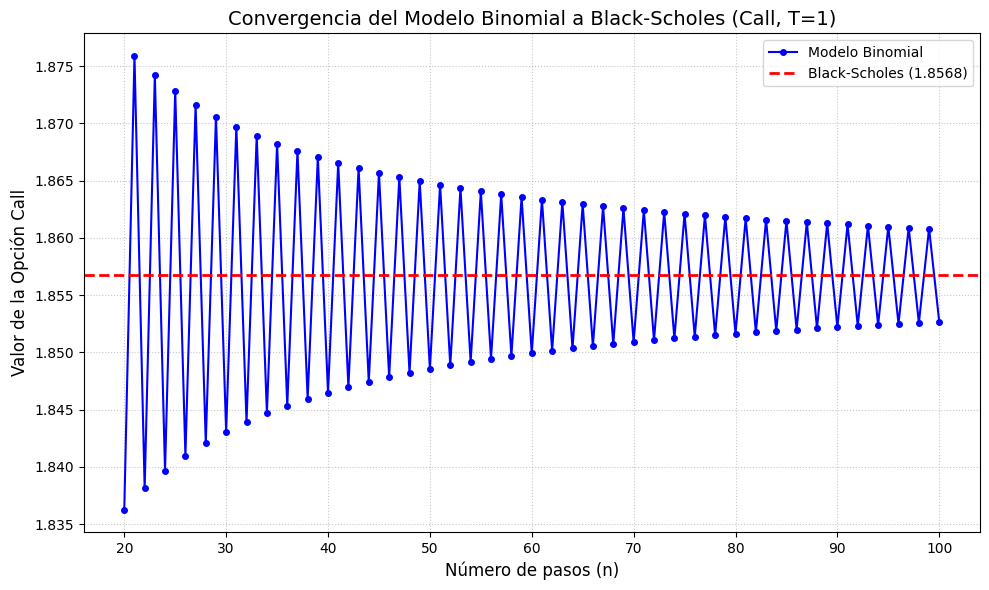

In [12]:
# 1. Funciones de Valoración
def valorar_opcion_binomial(S0, K, T, rc, sigma, dt):
    """Calcula solo el valor Call para optimizar el bucle."""
    n = int(round(T / dt))
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(rc * dt) - d) / (u - d)
    descuento = np.exp(-rc * T)

    k_vec = np.arange(0, n + 1)
    combinatoria = comb(n, k_vec)
    probabilidades = (p ** k_vec) * ((1 - p) ** (n - k_vec))

    ST = S0 * (u ** (2 * k_vec - n))
    payoffs_call = np.maximum(ST - K, 0)

    v_call = descuento * np.sum(combinatoria * probabilidades * payoffs_call)
    return v_call

def calcular_black_scholes_call(S, K, T, r, sigma):
    """Calcula el valor teórico Call de Black-Scholes."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call

# 2. Configuración de Parámetros - Asumiendo T=1
S0 = 14.0
K = 14.0
r_discreta = 0.03
rc = np.log(1 + r_discreta)
sigma = 0.3
T = 1.0

# 3. Cálculo del bucle (n de 20 a 100)
valores_n = np.arange(20, 101)
precios_call_binomial = []

for n in valores_n:
    dt = T / n
    call = valorar_opcion_binomial(S0, K, T, rc, sigma, dt)
    precios_call_binomial.append(call)

# Valor de referencia constante
call_bs_teorico = calcular_black_scholes_call(S0, K, T, rc, sigma)

# 4. Representación Gráfica
plt.figure(figsize=(10, 6))

# Trazamos la línea del modelo binomial
plt.plot(valores_n, precios_call_binomial, marker='o', markersize=4, linestyle='-',
         color='blue', label='Modelo Binomial')

# Trazamos la línea teórica de Black-Scholes
plt.axhline(y=call_bs_teorico, color='red', linestyle='--', linewidth=2,
            label=f'Black-Scholes ({call_bs_teorico:.4f})')

# Personalización del gráfico
plt.title('Convergencia del Modelo Binomial a Black-Scholes (Call, T=1)', fontsize=14)
plt.xlabel('Número de pasos (n)', fontsize=12)
plt.ylabel('Valor de la Opción Call', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Todo punto es estrictamente menor que el de dos instantes anteriores.
Último error alcanzado: 0.00412617


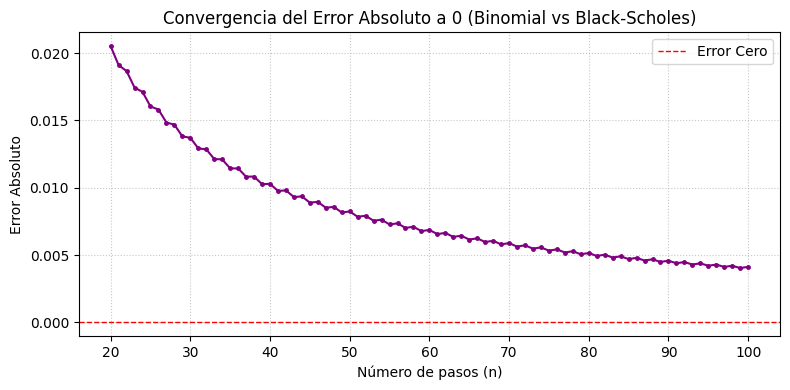

In [13]:
# 1. Calculamos el error absoluto (distancia) entre el Binomial y Black-Scholes
historial_real = np.abs(np.array(precios_call_binomial) - call_bs_teorico)

# 2. Tu función de comprobación
def verificar_decrecimiento_a_cero(historial):
    """
    Compara cada valor con el de dos instantes anteriores (i vs i-2)
    para confirmar que la secuencia decrece hacia cero.
    """
    historial = np.array(historial)
    decrece_siempre = True

    # Comprobar numéricamente (i vs i-2)
    for i in range(2, len(historial)):
        if historial[i] >= historial[i-2]:
            print(f"Atención: En el índice {i} (n={i+20}) el error ({historial[i]:.6f}) NO es menor que en el {i-2} ({historial[i-2]:.6f})")
            decrece_siempre = False

    if decrece_siempre:
        print("Todo punto es estrictamente menor que el de dos instantes anteriores.")

    print(f"Último error alcanzado: {historial[-1]:.8f}")

    # Comprobar visualmente que tiende a cero
    plt.figure(figsize=(8, 4))
    # Usamos valores_n (20 a 100) para el eje X en lugar del índice genérico
    valores_n = np.arange(20, 20 + len(historial))
    plt.plot(valores_n, historial, color='purple', linewidth=1.5, marker='.', markersize=5)
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Error Cero')
    plt.title('Convergencia del Error Absoluto a 0 (Binomial vs Black-Scholes)')
    plt.xlabel('Número de pasos (n)')
    plt.ylabel('Error Absoluto')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 3. Ejecutamos la función con los datos reales
verificar_decrecimiento_a_cero(historial_real)

### Práctica 6 - Apartado (b): Análisis de Convergencia del Modelo Binomial

En este apartado se representa gráficamente la evolución del precio de la opción call estimado mediante el árbol binomial para distintos valores del número de pasos, variando desde n=20 hasta n=100. Se utiliza como referencia constante la línea roja que representa el valor analítico exacto obtenido mediante la fórmula de Black-Scholes.

**¿Qué sucede al aumentar el número de pasos (n)?**

La conclusión fundamental es que el valor obtenido por el modelo binomial **converge** hacia el valor teórico continuo de Black-Scholes a medida que $n \to \infty$. Sin embargo, esta convergencia no es suave ni directa, sino que presenta un **comportamiento oscilatorio amortiguado**.

#### Análisis detallado de las gráficas resultantes:

1. **El fenómeno del "zig-zag" (Gráfica de Convergencia del Valor):**
   * Como se aprecia en la primera gráfica, el valor estimado rebota continuamente por encima y por debajo de la línea teórica de Black-Scholes.
   * Este comportamiento es un fenómeno matemático clásico de los árboles binomiales conocido como el **efecto de paridad** (o error de no linealidad del *Strike*). Ocurre porque la discretización del árbol hace que el precio de ejercicio (Strike) caiga entre los distintos nodos finales posibles. Dependiendo de si el número de pasos n es **par o impar**, la distribución de los nodos finales alrededor del Strike cambia ligeramente, provocando ese salto u oscilación sistemática en el cálculo de la prima.
   * A medida que incrementamos n, la malla de precios posibles se vuelve más densa y fina. En consecuencia, la amplitud de esta oscilación se reduce drásticamente (se amortigua) y el precio se estabiliza alrededor de la constante teórica.

2. **Evolución del Error Absoluto (Gráfica de Error a 0):**
   * La segunda gráfica confirma visualmente que la diferencia absoluta entre el precio binomial y Black-Scholes tiende a cero.
   * Tal y como señala el texto de comprobación del algoritmo (*"Todo punto es estrictamente menor que el de dos instantes anteriores"*), se demuestra matemáticamente la naturaleza de la convergencia: la sucesión completa no es monótona decreciente, pero sí lo son las **subsucesiones de pasos pares e impares por separado**. Comparar un salto con el de dos periodos atrás garantiza que estamos comparando distribuciones nodales equivalentes, mostrando una caída estricta del error.

**Conclusión:**
Las gráficas demuestran la viabilidad del método binomial para aproximar el modelo continuo. No obstante, ilustran que la precisión de una iteración n no siempre es estrictamente mejor que la de n-1 debido a las oscilaciones de paridad, aunque la tendencia global del error sí sea decreciente hacia cero.

Apartado c)

In [14]:
from scipy.special import bdtrc
import time

# 1. Configuración de parámetros
S0 = 14.0
K = 14.0
r_discreta = 0.03
rc = np.log(1 + r_discreta)
sigma = 0.3
T = 1.0
tolerancia = 1e-5

# Precalculamos el descuento para no hacerlo en cada iteración
K_descontado = K * np.exp(-rc * T)

# 2. Función con función C: bdtrc
def call_binomial(n):
    dt = T / n
    sqdt = np.sqrt(dt)
    u = np.exp(sigma * sqdt)
    d = 1.0 / u
    p = (np.exp(rc * dt) - d) / (u - d)

    # Probabilidad modificada p'
    p_prime = p * u * np.exp(-rc * dt)

    # Calcular el número mínimo de subidas (a) para que S_T > K
    limite_k = (n / 2.0) + np.log(K / S0) / (2.0 * sigma * sqdt)
    a = int(np.floor(limite_k)) + 1

    # Casos límite
    if a <= 0: return S0 - K_descontado # Si a <= 0, prob1 y prob2 son ~1
    if a > n: return 0.0

    # bdtrc(k, n, p) calcula P(X > k).
    # Como queremos P(X >= a), pasamos (a - 1)
    prob1 = bdtrc(a - 1, n, p_prime)
    prob2 = bdtrc(a - 1, n, p)

    return S0 * prob1 - K_descontado * prob2

# 3. Valor Teórico de Black-Scholes
d1 = (np.log(S0 / K) + (rc + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
V_BSM = S0 * norm.cdf(d1) - K_descontado * norm.cdf(d2)

# 4. Ejecución
inicio = time.time()

n_consecutivo = None
n_paridad = None
n_bsm = None

# Variables para guardar memoria de instantes anteriores
V_ant = call_binomial(1)
V_ant2 = call_binomial(2)

# Búsqueda simultánea (hasta 50,000 pasos)
for n in range(3, 50000):
    V_actual = call_binomial(n)

    # APARTADO 1: Diferencia entre iteración n y n-1
    if n_consecutivo is None and abs(V_actual - V_ant) < tolerancia:
        n_consecutivo = n

    # APARTADO 1 (Variante): Diferencia misma paridad n y n-2
    if n_paridad is None and abs(V_actual - V_ant2) < tolerancia:
        n_paridad = n

    # APARTADO 2: Diferencia con Black-Scholes
    if n_bsm is None and abs(V_actual - V_BSM) < tolerancia:
        n_bsm = n

    # Desplazar memoria
    V_ant2 = V_ant
    V_ant = V_actual

    # Si encontramos todos, paramos
    if n_consecutivo and n_paridad and n_bsm:
        break

fin = time.time()

# Resultados
print("-" * 50)
print(f"APARTADO 1 (Diferencia interna < 10^-5)")
print(f"  -> Consecutivos (n vs n-1): n = {n_consecutivo}")
print(f"  -> Misma paridad (n vs n-2): n = {n_paridad}")
print("-" * 50)
print(f"APARTADO 2 (Diferencia con Black-Scholes < 10^-5)")
print(f"  -> Convergencia BSM: n = {n_bsm}")
print("-" * 50)
print(f"Referencia BSM: {V_BSM:.6f}")
print(f"Tiempo de cómputo: {(fin - inicio):.4f} segundos")

--------------------------------------------------
APARTADO 1 (Diferencia interna < 10^-5)
  -> Consecutivos (n vs n-1): n = None
  -> Misma paridad (n vs n-2): n = 285
--------------------------------------------------
APARTADO 2 (Diferencia con Black-Scholes < 10^-5)
  -> Convergencia BSM: n = 39913
--------------------------------------------------
Referencia BSM: 1.856787
Tiempo de cómputo: 0.8376 segundos


### Práctica 6 - Apartado c): Análisis de Precisión y Convergencia Computacional

En esta sección final, se busca determinar el coste computacional (medido en número de pasos $n$) necesario para alcanzar un nivel de precisión extremo, fijado en un error umbral de $10^{-5}$. Se evalúan dos criterios distintos: la convergencia interna del propio modelo y la convergencia hacia el valor exacto continuo.

#### 1. Diferencia entre iteraciones (Convergencia interna)

* **Diferencia consecutiva ($n$ frente a $n-1$):** Resultado `None`. El algoritmo no encuentra un valor para el cual la diferencia consecutiva sea menor a $10^{-5}$. Esto confirma empíricamente el fenómeno del **efecto de paridad** (el "zig-zag") analizado en el apartado anterior. Al saltar entre un árbol de topología par y uno impar, la estimación rebota por encima y por debajo del valor central, impidiendo que la diferencia *consecutiva* caiga por debajo de un umbral tan restrictivo.
* **Diferencia con misma paridad ($n$ frente a $n-2$): $n = 285$ pasos.** Al evitar el salto de paridad y comparar iteraciones con la misma estructura final de nodos, la oscilación desaparece. Se observa que el modelo logra una gran estabilidad interna rápidamente: en apenas 285 pasos, el precio del árbol deja de variar en sus primeros cinco decimales respecto a sus iteraciones previas equivalentes.

#### 2. Convergencia hacia el modelo de Black-Scholes (BSM)

* **Diferencia absoluta (Binomial vs BSM) < $10^{-5}$:** **$n = 39913$ pasos.**

---

### Conclusión Final de la Práctica 6

Los resultados de esta última prueba revelan una característica crucial de los métodos numéricos en la valoración de derivados: **la diferencia entre la estabilidad de la discretización y la exactitud frente al modelo continuo**.

Aunque el árbol binomial se estabiliza consigo mismo con relativa rapidez (a partir de los ~300 pasos los cambios internos son microscópicos), lograr que esa aproximación discreta encaje casi perfectamente (a 5 decimales) con la curva continua teórica de Black-Scholes exige una carga computacional masiva, requiriendo en este caso rozar los 40.000 pasos.

Esto demuestra que, para opciones europeas vainilla, la evaluación de la fórmula cerrada de Black-Scholes es infinitamente superior en términos de eficiencia. El verdadero valor del método binomial no reside en buscar una precisión extrema para opciones europeas, sino en su capacidad para valorar opciones complejas (como las opciones americanas, que pueden ejercerse anticipadamente) donde las fórmulas cerradas estándar no son aplicables.